# Robustness and Sensitivity of the Frozen Optimizer Schedule

This notebook stress-tests the **already frozen nominal MILP schedule**.

The key methodological rule is:

> **Do not re-optimize first.** Apply the nominal schedule unchanged under plausible demand, leak, and receiver-model perturbations.

This asks a stricter question than nominal feasibility:

> If reality differs from the optimizer's assumptions, does the same recommendation remain within the modeled pressure, reserve, and terminal-pressure requirements?

All results in this notebook are **simulated evidence**.

A failed stress scenario is not treated as a notebook failure. It is a valid robustness result and must be reported rather than tuned away.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = Path.cwd().resolve()

if (
    not (ROOT / "ml").exists()
    and (ROOT.parent / "ml").exists()
):
    ROOT = ROOT.parent

if not (ROOT / "ml").exists():
    raise RuntimeError(
        "Could not locate repository root."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(ROOT),
    )

from ml.optimization.robustness import (
    RobustnessScenario,
    evaluate_scenarios,
)
from ml.optimization.scheduler import (
    OptimizationConfig,
    optimize_schedule,
)
from ml.twin.compressor import CompressorSpec
from ml.twin.physics import TwinParameters

print("Repository root:", ROOT)

Repository root: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor


## Load the frozen simulation and robustness assumptions

The robustness scenarios are declared in `configs/robustness.yaml` so the stress tests are explicit and reproducible.

In [2]:
with (
    ROOT
    / "configs"
    / "compressors.yaml"
).open(
    "r",
    encoding="utf-8",
) as handle:
    compressor_config = yaml.safe_load(handle)

with (
    ROOT
    / "configs"
    / "twin.yaml"
).open(
    "r",
    encoding="utf-8",
) as handle:
    twin_config = yaml.safe_load(handle)

with (
    ROOT
    / "configs"
    / "optimization.yaml"
).open(
    "r",
    encoding="utf-8",
) as handle:
    optimization_raw = yaml.safe_load(
        handle
    )["optimization"]

with (
    ROOT
    / "configs"
    / "robustness.yaml"
).open(
    "r",
    encoding="utf-8",
) as handle:
    robustness_raw = yaml.safe_load(
        handle
    )["robustness"]

compressors = [
    CompressorSpec(
        id=str(item["id"]),
        kind=str(item["kind"]),
        max_mass_flow_kg_s=float(
            item["max_mass_flow_kg_s"]
        ),
        rated_power_kw=float(
            item["rated_power_kw"]
        ),
        idle_power_kw=float(
            item["idle_power_kw"]
        ),
        min_load_fraction=float(
            item["min_load_fraction"]
        ),
        min_on_seconds=float(
            item["min_on_seconds"]
        ),
        min_off_seconds=float(
            item["min_off_seconds"]
        ),
    )
    for item in compressor_config[
        "compressors"
    ]
]

pressure_config = compressor_config[
    "pressure"
]

air_config = twin_config["air"]
receiver_config = twin_config["receiver"]

parameters = TwinParameters(
    volume_m3=float(
        receiver_config["volume_m3"]
    ),
    temperature_k=float(
        air_config["temperature_k"]
    ),
    gas_constant_j_per_kg_k=float(
        air_config[
            "gas_constant_j_per_kg_k"
        ]
    ),
    ambient_pressure_pa=float(
        air_config[
            "ambient_pressure_pa"
        ]
    ),
)

solver_raw = optimization_raw[
    "solver"
]

optimizer_config = OptimizationConfig(
    interval_seconds=float(
        optimization_raw[
            "interval_seconds"
        ]
    ),
    reserve_mass_flow_kg_s=float(
        optimization_raw[
            "reserve_mass_flow_kg_s"
        ]
    ),
    startup_penalty_kwh=float(
        optimization_raw[
            "startup_penalty_kwh"
        ]
    ),
    overpressure_penalty_kwh_per_bar_hour=float(
        optimization_raw[
            "overpressure_penalty_kwh_per_bar_hour"
        ]
    ),
    terminal_pressure_min_bar_g=float(
        optimization_raw[
            "terminal_pressure_min_bar_g"
        ]
    ),
    time_limit_seconds=float(
        solver_raw[
            "time_limit_seconds"
        ]
    ),
    mip_rel_gap=float(
        solver_raw[
            "mip_rel_gap"
        ]
    ),
)

nominal_leak_kg_s = float(
    compressor_config[
        "scenario"
    ][
        "nominal_leak_kg_s"
    ]
)

scenarios = [
    RobustnessScenario(
        id=str(item["id"]),
        demand_multiplier=float(
            item["demand_multiplier"]
        ),
        leak_delta_kg_s=float(
            item["leak_delta_kg_s"]
        ),
        volume_multiplier=float(
            item["volume_multiplier"]
        ),
    )
    for item in robustness_raw[
        "scenarios"
    ]
]

scenarios

[RobustnessScenario(id='nominal', demand_multiplier=1.0, leak_delta_kg_s=0.0, volume_multiplier=1.0),
 RobustnessScenario(id='demand_plus_5pct', demand_multiplier=1.05, leak_delta_kg_s=0.0, volume_multiplier=1.0),
 RobustnessScenario(id='demand_plus_10pct', demand_multiplier=1.1, leak_delta_kg_s=0.0, volume_multiplier=1.0),
 RobustnessScenario(id='leak_plus_0p005', demand_multiplier=1.0, leak_delta_kg_s=0.005, volume_multiplier=1.0),
 RobustnessScenario(id='leak_plus_0p010', demand_multiplier=1.0, leak_delta_kg_s=0.01, volume_multiplier=1.0),
 RobustnessScenario(id='volume_minus_10pct', demand_multiplier=1.0, leak_delta_kg_s=0.0, volume_multiplier=0.9),
 RobustnessScenario(id='volume_plus_10pct', demand_multiplier=1.0, leak_delta_kg_s=0.0, volume_multiplier=1.1)]

## Recreate the frozen nominal MILP schedule

This must reproduce notebook 07 before any stress test is interpreted.

In [3]:
block_seconds = 15 * 60
interval_seconds = int(
    optimizer_config.interval_seconds
)

intervals_per_block = (
    block_seconds
    // interval_seconds
)

nominal_demand = (
    [0.070] * intervals_per_block
    + [0.110] * intervals_per_block
    + [0.145] * intervals_per_block
    + [0.090] * intervals_per_block
)

optimized = optimize_schedule(
    nominal_demand,
    leak_mass_flow_kg_s=(
        nominal_leak_kg_s
    ),
    initial_pressure_bar_g=7.0,
    parameters=parameters,
    compressors=compressors,
    target_bar_g=float(
        pressure_config[
            "target_bar_g"
        ]
    ),
    safety_min_bar_g=float(
        pressure_config[
            "safety_min_bar_g"
        ]
    ),
    safety_max_bar_g=float(
        pressure_config[
            "safety_max_bar_g"
        ]
    ),
    config=optimizer_config,
)

schedule = optimized.schedule

print(
    "Frozen optimized energy:",
    optimized.energy_kwh,
    "kWh",
)

print(
    "Frozen pressure range:",
    schedule["pressure_bar_g"].min(),
    "to",
    schedule["pressure_bar_g"].max(),
    "bar(g)",
)

Frozen optimized energy: 25.217708333326183 kWh
Frozen pressure range: 6.5 to 7.39863155375289 bar(g)


## Replay the same schedule under every perturbation

The compressor commands do not change between scenarios. Only the assumed reality changes.

In [4]:
results = evaluate_scenarios(
    schedule,
    nominal_demand,
    nominal_leak_mass_flow_kg_s=(
        nominal_leak_kg_s
    ),
    initial_pressure_bar_g=7.0,
    nominal_parameters=parameters,
    compressors=compressors,
    interval_seconds=(
        optimizer_config.interval_seconds
    ),
    safety_min_bar_g=float(
        pressure_config[
            "safety_min_bar_g"
        ]
    ),
    safety_max_bar_g=float(
        pressure_config[
            "safety_max_bar_g"
        ]
    ),
    required_reserve_kg_s=(
        optimizer_config
        .reserve_mass_flow_kg_s
    ),
    terminal_pressure_min_bar_g=(
        optimizer_config
        .terminal_pressure_min_bar_g
    ),
    scenarios=scenarios,
)

summary = pd.DataFrame(
    [
        result.summary_dict()
        for result in results
    ]
)

summary[
    [
        "scenario",
        "minimum_pressure_bar_g",
        "maximum_pressure_bar_g",
        "terminal_pressure_bar_g",
        "minimum_safety_margin_bar",
        "safety_violation_intervals",
        "reserve_violation_intervals",
        "terminal_requirement_met",
        "safe",
    ]
]

,scenario,minimum_pressure_bar_g,maximum_pressure_bar_g,terminal_pressure_bar_g,minimum_safety_margin_bar,safety_violation_intervals,reserve_violation_intervals,terminal_requirement_met,safe
0,nominal,6.500000,7.398632,7.000000,-8.881784e-15,0,0,True,True
1,demand_plus_5pct,5.193751,7.000000,5.401720,-1.306249e+00,44,0,False,False
2,demand_plus_10pct,3.618578,7.000000,3.803439,-2.881422e+00,45,0,False,False
3,leak_plus_0p005,5.254087,7.000000,5.459489,-1.245913e+00,45,0,False,False
4,leak_plus_0p010,3.739251,7.000000,3.918978,-2.760749e+00,50,0,False,False
5,volume_minus_10pct,6.444444,7.442924,7.000000,-5.555556e-02,20,0,True,False
6,volume_plus_10pct,6.545455,7.362392,7.000000,4.545455e-02,0,0,True,True


## Validate the replay implementation against the nominal optimizer

The nominal replay should reproduce the optimizer's nominal pressure trajectory. This gate validates the stress-test machinery; it does **not** require stressed scenarios to remain safe.

In [5]:
result_by_id = {
    result.scenario.id: result
    for result in results
}

nominal_replay = result_by_id[
    "nominal"
]

nominal_pressure_error = (
    nominal_replay.trajectory[
        "pressure_end_bar_g"
    ].to_numpy()
    - schedule[
        "pressure_bar_g"
    ].to_numpy()
)

max_nominal_pressure_error_bar = float(
    abs(
        nominal_pressure_error
    ).max()
)

nominal_energy_error_kwh = abs(
    nominal_replay.energy_kwh
    - optimized.energy_kwh
)

execution_acceptance = {
    "nominal_scenario_present": (
        "nominal" in result_by_id
    ),
    "stress_scenarios_present": (
        len(results) > 1
    ),
    "nominal_pressure_replay_matches": (
        max_nominal_pressure_error_bar
        <= float(
            robustness_raw[
                "replay_tolerance_bar"
            ]
        )
    ),
    "nominal_energy_replay_matches": (
        nominal_energy_error_kwh
        <= 1.0e-10
    ),
    "nominal_has_no_safety_violations": (
        nominal_replay
        .safety_violation_intervals
        == 0
    ),
    "nominal_has_no_reserve_violations": (
        nominal_replay
        .reserve_violation_intervals
        == 0
    ),
    "nominal_terminal_requirement_met": (
        nominal_replay
        .terminal_requirement_met
    ),
}

execution_acceptance[
    "all_passed"
] = all(
    execution_acceptance.values()
)

print(
    "Max nominal pressure replay error:",
    max_nominal_pressure_error_bar,
    "bar",
)

print(
    "Nominal energy replay error:",
    nominal_energy_error_kwh,
    "kWh",
)

pd.Series(
    execution_acceptance,
    name="passed",
)

Max nominal pressure replay error: 1.0292211527485051e-11 bar
Nominal energy replay error: 7.815970093361102e-14 kWh


nominal_scenario_present             True
stress_scenarios_present             True
nominal_pressure_replay_matches      True
nominal_energy_replay_matches        True
nominal_has_no_safety_violations     True
nominal_has_no_reserve_violations    True
nominal_terminal_requirement_met     True
all_passed                           True
Name: passed, dtype: bool

In [6]:
if not execution_acceptance[
    "all_passed"
]:
    raise RuntimeError(
        "Robustness execution acceptance "
        "gate failed."
    )

print(
    "Robustness execution acceptance gate: PASS"
)

Robustness execution acceptance gate: PASS


## Robustness outcome

A stress-test failure is reported directly. It does not invalidate the nominal MILP result; it limits how broadly that result may be claimed.

In [7]:
stress_results = [
    result
    for result in results
    if result.scenario.id != "nominal"
]

unsafe_scenarios = [
    result.scenario.id
    for result in stress_results
    if not result.safe
]

all_tested_perturbations_safe = (
    len(unsafe_scenarios) == 0
)

robustness_status = (
    "robust_to_tested_perturbations"
    if all_tested_perturbations_safe
    else (
        "nominal_feasible_but_not_robust_"
        "to_tested_perturbations"
    )
)

print(
    "Robustness status:",
    robustness_status,
)

print(
    "Unsafe stress scenarios:",
    unsafe_scenarios,
)

print(
    "Worst tested minimum pressure:",
    summary[
        "minimum_pressure_bar_g"
    ].min(),
    "bar(g)",
)

Robustness status: nominal_feasible_but_not_robust_to_tested_perturbations
Unsafe stress scenarios: ['demand_plus_5pct', 'demand_plus_10pct', 'leak_plus_0p005', 'leak_plus_0p010', 'volume_minus_10pct']
Worst tested minimum pressure: 3.6185778391647427 bar(g)


## Pressure trajectories

Because the simplified receiver model has constant pressure derivative within each 60-second command interval, endpoint violations are sufficient to identify interval safety violations under this model.

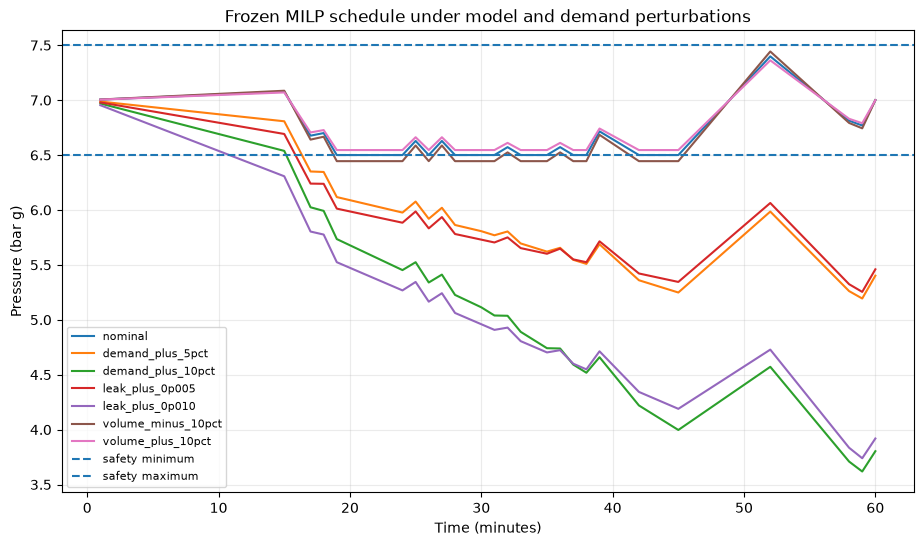

In [8]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for result in results:
    trajectory = result.trajectory

    ax.plot(
        trajectory["time_seconds"]
        / 60.0,
        trajectory[
            "pressure_end_bar_g"
        ],
        label=result.scenario.id,
    )

ax.axhline(
    float(
        pressure_config[
            "safety_min_bar_g"
        ]
    ),
    linestyle="--",
    label="safety minimum",
)

ax.axhline(
    float(
        pressure_config[
            "safety_max_bar_g"
        ]
    ),
    linestyle="--",
    label="safety maximum",
)

ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Pressure (bar g)")
ax.set_title(
    "Frozen MILP schedule under "
    "model and demand perturbations"
)
ax.legend(
    loc="best",
    fontsize=8,
)
ax.grid(alpha=0.25)

plt.show()

## Write the robustness evidence report

The report distinguishes:

- successful execution of the stress-test machinery,
- nominal feasibility,
- robustness (or lack of robustness) to the declared perturbations.

No real-plant robustness claim is made.

In [9]:
REPORT_PATH = (
    ROOT
    / "docs"
    / "robustness_report.json"
)

report = {
    "evidence_class": "simulated",
    "method": (
        "open_loop_replay_of_frozen_"
        "nominal_optimizer_schedule"
    ),
    "execution_acceptance": (
        execution_acceptance
    ),
    "nominal_replay": {
        "max_pressure_error_bar": (
            max_nominal_pressure_error_bar
        ),
        "energy_error_kwh": (
            nominal_energy_error_kwh
        ),
    },
    "robustness": {
        "status": robustness_status,
        "all_tested_perturbations_safe": (
            all_tested_perturbations_safe
        ),
        "unsafe_scenarios": (
            unsafe_scenarios
        ),
        "worst_tested_minimum_pressure_bar_g":
            float(
                summary[
                    "minimum_pressure_bar_g"
                ].min()
            ),
    },
    "scenarios": [
        result.summary_dict()
        for result in results
    ],
    "limitations": [
        (
            "This is an open-loop replay "
            "of the frozen nominal schedule."
        ),
        (
            "The optimizer is not "
            "re-optimized during the stress "
            "scenarios."
        ),
        (
            "The compressor power model "
            "depends on commands rather than "
            "pressure-dependent efficiency, "
            "so replay energy can remain "
            "unchanged across perturbations."
        ),
        (
            "The perturbation magnitudes are "
            "scenario assumptions, not "
            "measured uncertainty bounds "
            "from a real plant."
        ),
        (
            "Failure of a stress scenario "
            "means the nominal schedule "
            "should not be described as "
            "robust to that perturbation."
        ),
        (
            "AeroXAI remains advisory-only "
            "and does not override equipment "
            "control."
        ),
    ],
}

REPORT_PATH.write_text(
    json.dumps(
        report,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Robustness report written to:",
    REPORT_PATH,
)

Robustness report written to: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor/docs/robustness_report.json


## Interpretation rule

If one or more stress scenarios fail, keep the nominal optimizer result unchanged and report the limitation.

The next engineering step is **not** to tune the experiment until every scenario passes. Instead, use the result to decide whether the MVP should:

1. add a conservative planning margin,
2. re-optimize from updated telemetry in a receding-horizon workflow,
3. expose a robustness/safety gate to the operator,
4. or combine these approaches.

That decision is made after reviewing the actual stress-test results.